In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
from collections import OrderedDict
from PIL import Image
from torchvision import transforms
import torchvision
from torchvision import models
from torchvision.utils import save_image
import numpy as np
import matplotlib.pyplot as plt

from collections import OrderedDict
from stylegan_implementation import G_mapping, G_synthesis

In [ ]:
g_all = nn.Sequential(OrderedDict([
    ('g_mapping', G_mapping()),
    ('g_synthesis', G_synthesis())
]))

g_mapping = g_all[0]
g_synthesis = g_all[1]

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("songseungwon/ffhq-1024x1024-pretrained")

print("Path to dataset files:", path)

100%|██████████| 92.8M/92.8M [00:01<00:00, 68.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/songseungwon/ffhq-1024x1024-pretrained/versions/1


In [4]:
import os
os.listdir('/root/.cache/kagglehub/datasets/songseungwon/ffhq-1024x1024-pretrained/versions/1')

['karras2019stylegan-ffhq-1024x1024.for_g_all.pt']

In [5]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
g_all = nn.Sequential(OrderedDict([
    ('g_mapping', G_mapping()),
    ('g_synthesis', G_synthesis())
]))

#Load the pre-trained model
g_all.load_state_dict(torch.load(path + '/karras2019stylegan-ffhq-1024x1024.for_g_all.pt', map_location=device))
g_all.eval()
g_all.to(device)
g_mapping, g_synthesis = g_all[0],g_all[1]

<ipython-input-5-9800c2a3cc0b>:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  g_all.load_state_dict(torch.load(path + '/karras2019stylegan-ffhq-1024x1024.for_g_all.pt', ma

In [8]:
#Read a sample image we want to find a latent vector for
img_path = 'transformed_face.png'
with open(img_path,"rb") as f:
  image1=Image.open(f)
  image1=image1.convert("RGB")
transform = transforms.Compose([
    transforms.ToTensor()
])
image1 = transform(image1)
image1 = image1.unsqueeze(0)
image1 = image1.to(device)
print(image1.shape)

torch.Size([1, 3, 1024, 1024])


VGG Perceptual loss network to give feature vectors from 4 parts of the pre-trained VGG-16 from 2,4,14,21

In [9]:
class VGG16_perceptual(torch.nn.Module):
    def __init__(self, requires_grad=False):
        super(VGG16_perceptual, self).__init__()
        vgg_pretrained_features = models.vgg16(pretrained=True).features
        self.slice1 = torch.nn.Sequential()
        self.slice2 = torch.nn.Sequential()
        self.slice3 = torch.nn.Sequential()
        self.slice4 = torch.nn.Sequential()
        for x in range(2):
            self.slice1.add_module(str(x), vgg_pretrained_features[x])
        for x in range(2, 4):
            self.slice2.add_module(str(x), vgg_pretrained_features[x])
        for x in range(4, 14):
            self.slice3.add_module(str(x), vgg_pretrained_features[x])
        for x in range(14, 21):
            self.slice4.add_module(str(x), vgg_pretrained_features[x])
        if not requires_grad:
            for param in self.parameters():
                param.requires_grad = False

    def forward(self, X):
        h = self.slice1(X)
        h_relu1_1 = h
        h = self.slice2(h)
        h_relu1_2 = h
        h = self.slice3(h)
        h_relu3_2 = h
        h = self.slice4(h)
        h_relu4_2 = h
        return h_relu1_1, h_relu1_2, h_relu3_2, h_relu4_2

Loss function to calculate MSE and Perceptual losses


In [10]:
def loss_function(syn_img, img, img_p, MSE_loss, upsample, perceptual):

  # Find MSE loss between the real and synthesized images of actual size
  syn_img_p = upsample(syn_img)
  syn0, syn1, syn2, syn3 = perceptual(syn_img_p)
  r0, r1, r2, r3 = perceptual(img_p)
  mse = MSE_loss(syn_img,img)

  per_loss = 0
  per_loss += MSE_loss(syn0,r0)
  per_loss += MSE_loss(syn1,r1)
  per_loss += MSE_loss(syn2,r2)
  per_loss += MSE_loss(syn3,r3)

  return mse, per_loss

Embedding Function to optimise the latent code W+ for GAN inversion.


In [43]:
def embedding_function(image):
  upsample = torch.nn.Upsample(scale_factor = 256/1024, mode = 'bilinear')
  img_p = image.clone()
  img_p = upsample(img_p)
  # Perceptual loss initialise object
  perceptual = VGG16_perceptual().to(device)
  r0, r1, r2, r3 = perceptual(img_p)

  # MSE loss object
  MSE_loss = nn.MSELoss(reduction="mean")
  # initialize latent vector with suiting dimensionality
  latents = torch.zeros((1,18,512), requires_grad = True, device = device)
  #Optimizer to change latent code in each backward step
  optimizer = optim.Adam({latents},lr=0.01,betas=(0.9,0.999),eps=1e-8)


  loss_ = []
  # optimise latent vector to match the generated image to input image
  for e in range(3000):
    optimizer.zero_grad()
    syn_img = g_synthesis(latents)
    syn_img = (syn_img+1.0)/2.0

    # calculate losses
    mse, per_loss = loss_function(syn_img, image, img_p, MSE_loss, upsample, perceptual)
    loss = 0.4 * per_loss + 0.6 * mse

    loss.backward()
    optimizer.step()

    loss_np=loss.detach().cpu().numpy()
    loss_p=per_loss.detach().cpu().numpy()
    loss_m=mse.detach().cpu().numpy()

    loss_.append(loss_np)

    # print losses every 100th iteration
    if (e+1)%100==0 :
      print("iter{}: loss -- {},  mse_loss -- {},  percep_loss -- {}".format(e+1,loss_np,loss_m,loss_p))


    # save image every 500th iteration
    if (e + 1) % 500 == 0:
      save_image(syn_img.clamp(0,1),"face_{}_iterations.png".format(e+1))


  plt.plot(loss_, label = 'Loss = MSELoss + Perceptual')
  plt.legend()
  return latents

iter100: loss -- 1.4794546365737915,  mse_loss -- 0.053660012781620026,  percep_loss -- 3.6181464195251465
iter200: loss -- 1.2053593397140503,  mse_loss -- 0.04240664839744568,  percep_loss -- 2.9497880935668945
iter300: loss -- 1.0383594036102295,  mse_loss -- 0.038107432425022125,  percep_loss -- 2.5387372970581055
iter400: loss -- 0.9508057236671448,  mse_loss -- 0.03398618847131729,  percep_loss -- 2.3260350227355957
iter500: loss -- 0.8551483750343323,  mse_loss -- 0.03242712840437889,  percep_loss -- 2.0892302989959717
iter600: loss -- 0.7927278876304626,  mse_loss -- 0.029717793688178062,  percep_loss -- 1.9372429847717285
iter700: loss -- 0.7934306859970093,  mse_loss -- 0.028659574687480927,  percep_loss -- 1.9405872821807861
iter800: loss -- 0.716748833656311,  mse_loss -- 0.027063537389039993,  percep_loss -- 1.7512768507003784
iter900: loss -- 0.6956447958946228,  mse_loss -- 0.0261891670525074,  percep_loss -- 1.6998281478881836
iter1000: loss -- 0.6519763469696045,  mse_

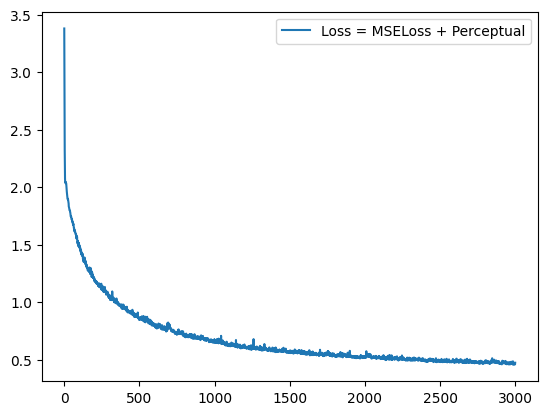

In [44]:
latent1 = embedding_function(image1)

-------
## Age Transformation

In [45]:
img1 = g_synthesis(latent1)
img1 = img1.clamp(-1,1)+1/2.0
img1 = img1.cpu()

img1.shape

torch.Size([1, 3, 1024, 1024])

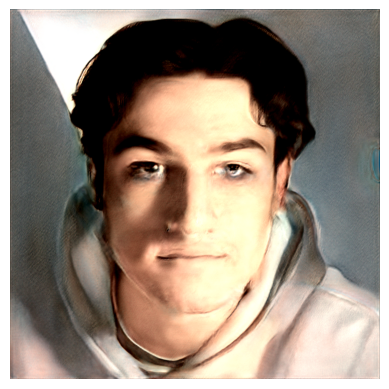

In [46]:
plt.imshow(img1.squeeze().permute(1,2,0).detach().numpy()) # drop batch (4dim -> 3dim)
plt.axis('off')
plt.show()

In [47]:
import gdown

# URL of the npy file on Google Drive
url = "https://drive.google.com/uc?id=1-fYz2hSegMjkohBq26Fdx6eGkyGaKe1r"

file = "stylegan_ffhq_age_w_boundary.npy"

# Check if the file already exists locally
if not os.path.exists(file):
    # If the file does not exist, download it from Google Drive
    print("Downloading the file...")
    gdown.download(url, file)
else:
    print("File already exists")

File already exists


In [48]:
# Load the boundary file
age_boundary = np.load("/content/stylegan_ffhq_age_w_boundary.npy", allow_pickle=True)
age_boundary = torch.tensor(age_boundary, dtype=torch.float32).unsqueeze(0)
age_boundary = age_boundary.to(device)

In [60]:
def manipulate_latent(w, boundary, alpha):
    return w + alpha * boundary

# Manipulate for aging
alpha = 4.0  # Change this value to control aging intensity

aged_w = manipulate_latent(latent1, age_boundary, alpha)

In [61]:
aged_img = g_synthesis(aged_w)
aged_img = (aged_img + 1.0) / 2.0  # Normalize to [0, 1]
aged_img = aged_img.cpu()

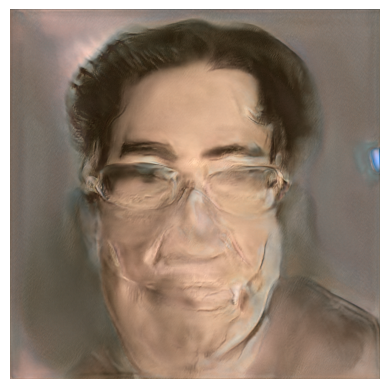

In [62]:
plt.imshow(aged_img.squeeze().permute(1,2,0).detach().numpy()) # drop batch (4dim -> 3dim)
plt.axis('off')
plt.show()

In [63]:
interpolated_images = []

with torch.no_grad():
    for a in np.linspace(0, 1, 10):
        z = ((1-a) * latent1) + (a * aged_w)
        result = g_synthesis(z)
        result = result.clamp(-1,1)+1/2.0
        result = result.cpu()
        interpolated_images.append(result)

In [64]:
itp_imgs = torch.cat(interpolated_images)
itp_imgs.size()

torch.Size([10, 3, 1024, 1024])

In [65]:
grid_img = torchvision.utils.make_grid(itp_imgs, nrow=5)
grid_img.size()

torch.Size([3, 2054, 5132])

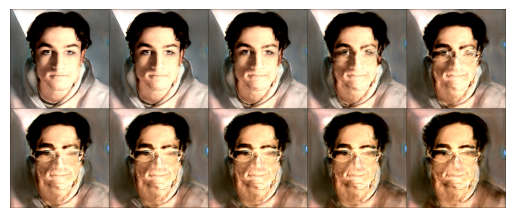

In [66]:
plt.imshow(grid_img.permute(1,2,0).detach().numpy())
plt.axis('off')
plt.show()